In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)


In [4]:
data_path = "/content/drive/MyDrive/Major Project/Data/smart_manufacturing_data.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [5]:
num_features = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption'
]

cat_features = [
    'machine_status',
    'machine_id'
]

X = df[num_features + cat_features]
y = df['anomaly_flag']  # evaluation only


In [6]:
X_train = X[y == 0]   # normal data only
X_test = X           # full data for evaluation


In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)


In [8]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


**Isolation Forest**

In [9]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_train_processed)


IsolationForest(contamination=0.05, random_state=42)

AutoEncoder layers

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled  = scaler.transform(X_test_processed)

# Convert sparse to dense
X_train_dense = X_train_scaled.toarray()
X_test_dense  = X_test_scaled.toarray()

# Build Autoencoder
input_dim = X_train_dense.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
encoded = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")



In [11]:
# reconstruction error as anomaly score
mse = np.mean(np.power(X_test_dense - autoencoder.predict(X_test_dense), 2), axis=1)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


# **By using AND Ensemble Technique**

In [12]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y, mse)

# Avoid division by zero
eps = 1e-10

f1_scores = 2 * (precision * recall) / (precision + recall + eps)

# Find best threshold
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)


Best Threshold: 1.214670808136037
Best F1 Score: 0.4011608222000385


Prediction

In [13]:
# Autoencoder prediction
th = best_threshold
ae_pred = np.where(mse > th, 1, 0)

# Isolation Forest prediction
iso_pred = iso.predict(X_test_processed)
iso_pred = np.where(iso_pred == -1, 1, 0)


**Ensemble Rule**

In [14]:
# Both must agree to mark anomaly
ensemble_pred = np.where((ae_pred == 1) & (iso_pred == 1), 1, 0)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y, ensemble_pred))
print(confusion_matrix(y, ensemble_pred))


              precision    recall  f1-score   support

           0       0.91      0.98      0.95     91084
           1       0.28      0.06      0.10      8916

    accuracy                           0.90    100000
   macro avg       0.60      0.52      0.53    100000
weighted avg       0.86      0.90      0.87    100000

[[89665  1419]
 [ 8356   560]]


**Increasing the threshold value using Precision**

In [16]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y, mse)

# Define desired precision
desired_precision = 0.30

best_th = 0
best_recall = 0

for p, r, th in zip(precision, recall, thresholds):
    if p >= desired_precision and r > best_recall:
        best_recall = r
        best_th = th

print("Best Threshold:", best_th)
print("Recall at Precision >= 0.30:", best_recall)


Best Threshold: 1.1921616761952694
Recall at Precision >= 0.30: 0.566397487662629


In [17]:
y_pred_new = np.where(mse > best_th, 1, 0)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y, y_pred_new))
print(confusion_matrix(y, y_pred_new))


              precision    recall  f1-score   support

           0       0.95      0.87      0.91     91084
           1       0.30      0.57      0.39      8916

    accuracy                           0.84    100000
   macro avg       0.63      0.72      0.65    100000
weighted avg       0.90      0.84      0.86    100000

[[79302 11782]
 [ 3866  5050]]


# **By using OR Ensemble Technique**

In [18]:
# 1) AE threshold that gives precision >= 0.30
th = best_th

# 2) AE predictions
ae_pred = np.where(mse > th, 1, 0)

# 3) IF predictions
iso_pred = iso.predict(X_test_processed)
iso_pred = np.where(iso_pred == -1, 1, 0)

# 4) OR ensemble
ensemble_pred = np.where((ae_pred == 1) | (iso_pred == 1), 1, 0)

# 5) Evaluate
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y, ensemble_pred))
print(confusion_matrix(y, ensemble_pred))


              precision    recall  f1-score   support

           0       0.95      0.84      0.89     91084
           1       0.26      0.58      0.36      8916

    accuracy                           0.82    100000
   macro avg       0.61      0.71      0.63    100000
weighted avg       0.89      0.82      0.85    100000

[[76675 14409]
 [ 3739  5177]]


**Saving The Models**

In [19]:
import joblib, json, os

BASE_PATH = "/content/drive/MyDrive/Major Project/Models/AutoEncoderAndIsolationForest"

# Create folder if it doesn't exist
os.makedirs(BASE_PATH, exist_ok=True)

# Save Autoencoder
autoencoder.save(f"{BASE_PATH}/autoencoder.keras")

# Save scaler
joblib.dump(scaler, f"{BASE_PATH}/scaler.pkl")

# Save Isolation Forest
joblib.dump(iso, f"{BASE_PATH}/isolation_forest.pkl")

# Save threshold
with open(f"{BASE_PATH}/ae_threshold.json", "w") as f:
    json.dump({"threshold": float(best_th)}, f)

print("✅ ALL MODELS SAVED SUCCESSFULLY in AutoEncoderAndIsolationForest")


✅ ALL MODELS SAVED SUCCESSFULLY in AutoEncoderAndIsolationForest


# **Ensemble Score using Alpha and Beta values**



In [20]:
iso_score = -iso.decision_function(X_test_processed)
ae_score = mse  # already computed
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scores = scaler.fit_transform(np.vstack([ae_score, iso_score]).T)


alpha = 0.6  # AE weight
beta  = 0.4  # IF weight

ensemble_score = alpha * scores[:,0] + beta * scores[:,1]
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y, ensemble_score)

# choose threshold with precision >= 0.30 and max recall
best_th = 0
best_recall = 0
for p, r, th in zip(precision, recall, thresholds):
    if p >= 0.30 and r > best_recall:
        best_recall = r
        best_th = th

y_pred = np.where(ensemble_score > best_th, 1, 0)


from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.96      0.94     91084
           1       0.30      0.16      0.21      8916

    accuracy                           0.89    100000
   macro avg       0.61      0.56      0.57    100000
weighted avg       0.87      0.89      0.88    100000

[[87821  3263]
 [ 7517  1399]]


In [21]:
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.preprocessing import MinMaxScaler

iso_score = -iso.decision_function(X_test_processed)
ae_score = mse

scaler = MinMaxScaler()
scores = scaler.fit_transform(np.vstack([ae_score, iso_score]).T)

best_result = None

for alpha in [0.2, 0.4, 0.6, 0.8]:
    beta = 1 - alpha
    ensemble_score = alpha * scores[:,0] + beta * scores[:,1]

    precision, recall, thresholds = precision_recall_curve(y, ensemble_score)

    # find best threshold for precision >= 0.30
    best_th = 0
    best_recall = 0
    for p, r, th in zip(precision, recall, thresholds):
        if p >= 0.30 and r > best_recall:
            best_recall = r
            best_th = th

    y_pred = np.where(ensemble_score > best_th, 1, 0)

    # evaluate
    from sklearn.metrics import classification_report
    report = classification_report(y, y_pred, output_dict=True)
    f1 = report['1']['f1-score']
    prec = report['1']['precision']
    rec = report['1']['recall']

    if best_result is None or rec > best_result['recall']:
        best_result = {
            'alpha': alpha,
            'beta': beta,
            'threshold': best_th,
            'precision': prec,
            'recall': rec,
            'f1': f1
        }

print(best_result)


{'alpha': 0.8, 'beta': 0.19999999999999996, 'threshold': np.float64(0.38515907962275964), 'precision': 0.30003508156463776, 'recall': 0.38369223867205027, 'f1': 0.33674574269120977}


In [22]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score

precision, recall, thresholds = precision_recall_curve(y, ensemble_score)

best_f1 = 0
best_th = 0

for p, r, th in zip(precision, recall, thresholds):
    f1 = 2 * (p*r)/(p+r+1e-10)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print("Best F1:", best_f1)
print("Best threshold:", best_th)


Best F1: 0.34955018517472963
Best threshold: 0.3443837526769633


In [23]:
y_pred = np.where(ensemble_score > best_th, 1, 0)
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.84      0.89     91084
           1       0.25      0.56      0.35      8916

    accuracy                           0.82    100000
   macro avg       0.60      0.70      0.62    100000
weighted avg       0.89      0.82      0.84    100000

[[76609 14475]
 [ 3963  4953]]


In [24]:
import joblib, json
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler


In [25]:
BASE_PATH = "/content/drive/MyDrive/Major Project/Models/AutoEncoderAndIsolationForest"

# Load models
autoencoder = load_model(f"{BASE_PATH}/autoencoder.keras")
scaler = joblib.load(f"{BASE_PATH}/scaler.pkl")
iso = joblib.load(f"{BASE_PATH}/isolation_forest.pkl")

# Load threshold
with open(f"{BASE_PATH}/ae_threshold.json") as f:
    best_th = json.load(f)["threshold"]

print("✅ Models loaded successfully")


✅ Models loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [26]:
# Scale & convert
X_test_scaled = scaler.transform(X_test_processed)
X_test_dense = X_test_scaled.toarray()

# Autoencoder reconstruction error
ae_score = np.mean(
    np.square(X_test_dense - autoencoder.predict(X_test_dense)),
    axis=1
)

# Isolation Forest score
iso_score = -iso.decision_function(X_test_processed)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [27]:
from sklearn.preprocessing import MinMaxScaler

score_scaler = MinMaxScaler()
scores = score_scaler.fit_transform(
    np.vstack([ae_score, iso_score]).T
)

alpha, beta = 0.8, 0.2
ensemble_score = alpha * scores[:, 0] + beta * scores[:, 1]


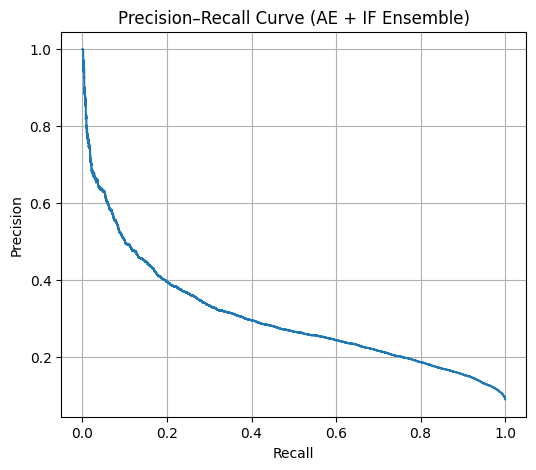

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y, ensemble_score)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (AE + IF Ensemble)")
plt.grid(True)
plt.show()


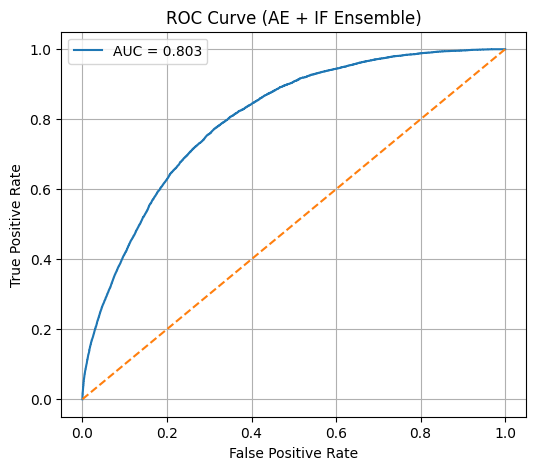

In [29]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y, ensemble_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AE + IF Ensemble)")
plt.legend()
plt.grid(True)
plt.show()


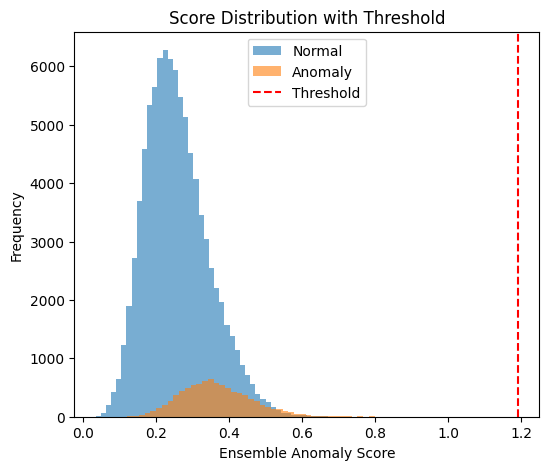

In [30]:
plt.figure(figsize=(6,5))
plt.hist(ensemble_score[y==0], bins=50, alpha=0.6, label="Normal")
plt.hist(ensemble_score[y==1], bins=50, alpha=0.6, label="Anomaly")
plt.axvline(best_th, color="red", linestyle="--", label="Threshold")
plt.xlabel("Ensemble Anomaly Score")
plt.ylabel("Frequency")
plt.title("Score Distribution with Threshold")
plt.legend()
plt.show()


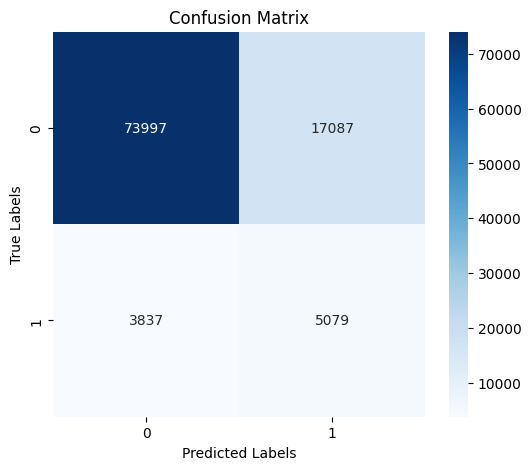

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated confusion matrix values
conf_matrix = np.array([[73997, 17087],
 [3837, 5079]])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
